# Regular TransE

In [1]:
!pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 261.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 212.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 249.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 283.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 163.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pickle
import torch.nn as nn
import torch.optim as optim
import random
from torch.utils.data import Dataset, DataLoader
import re
import os
import json
from keybert import KeyBERT
import ast
from datetime import datetime


Add the location of your preprocessed files below

In [3]:
csv_file = '../preprocess/'

Import CPE

In [4]:
df_cpe = pd.read_csv(csv_file + "csv_file/2021aug/cpe_ignore_version.csv", usecols=['part','vendor',
                'product', 'target_sw','target_hw','name','size']).sort_values(
                'size', ascending=False)

Import CVE

In [5]:
df_cve = pd.read_csv(csv_file + "csv_file/2021aug/cve/cve-2002.csv")
df_cve = df_cve.astype('object').fillna('*')
df_list = [df_cve]
for i in range(2003, 2022):
    filename = f'{csv_file}csv_file/2021aug/cve/cve-{i}.csv'
    df_temp = pd.read_csv(filename)
    df_temp = df_temp.astype('object').fillna('*')
    df_list.append(df_temp)
df_cve = pd.concat(df_list, ignore_index=True)


Import CWE

In [6]:
df_cwe = pd.read_csv(csv_file + "csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv(csv_file + "csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv(csv_file + "csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

In [7]:
kw_model = KeyBERT()

def extract_keywords(text, top_k=3):
    if not isinstance(text, str):
        return []
    keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=(1, 1), stop_words='english', top_n=top_k)
    return [kw for kw, _ in keywords]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
triples_key = []
for _, row in df_cwe.iterrows():
    cve_id = row['ID']
    desc = row['Name']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])

for _, row in df_cwe_cate.iterrows():
    cve_id = row['ID']
    desc = row['Name']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])


for _, row in df_cwe_view.iterrows():
    cve_id = row['ID']
    desc = row['Name']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])


In [9]:
print("The size of df_cpe, df_cve, df_cwe are:", df_cpe.shape[0], df_cve.shape[0], df_cwe.shape[0])

The size of df_cpe, df_cve, df_cwe are: 68338 167542 918


In [10]:
cwe_list = []

kg_cwe = []

for i, r in df_cwe.iterrows():
    cweid = r['ID']

    cwe_list.append(cweid)

    if (r['Related_Weakness'] != '*'):
        relatedlist = r['Related_Weakness'].split(';')
        for re in relatedlist:
            relation, other = re.split(':')
            other = 'CWE-' + other
            kg_cwe.append(([cweid, relation, other]))

    if (r['Language'] != '*'):
        langlist = r['Language'].split(';')
        for l in langlist:
            if (l != 'Language-Independent'):
                kg_cwe.append(([cweid, 'Language', l]))

    if (r['Technology'] != '*'):
        techlist = r['Technology'].split(';')
        for t in techlist:
            if (t != 'Technology-Independent'):
                kg_cwe.append(([cweid, 'Technology', t]))

    if (r['Likelihood_Of_Exploit'] != '*'):
        kg_cwe.append(([cweid, 'LikelihoodOfExploit', \
                        r['Likelihood_Of_Exploit']]))

    if (r['Consequence'] != '*'):
        conseqlist = r['Consequence'].split(';')
        for c in conseqlist:
            if (c != 'Other'):
                kg_cwe.append(([cweid, 'Consequence', c]))

In [11]:
kg_cate = []
kg_view = []

for i, r in df_cwe_cate.iterrows():
    cid = r['ID']

    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_cate.append(([cid, 'Has_Member', m]))

for i, r in df_cwe_view.iterrows():
    vid = r['ID']

    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_view.append(([vid, 'Has_Member', m]))

In [12]:
cpe_candidate_list = df_cpe['name'].values.tolist()

In [13]:
cve_candidate_list = []
connected_cvelist = []

kg_cve = []
kg_cpe2cve = []
kg_cve2cwe = []

connected_cpelist = []

for i, r in tqdm(df_cve.iterrows(), total = len(df_cve)):
    cveid = r['ID']
    cve_candidate_list.append(cveid)
    is_connected = 0

    if (r['MatchingCPE'] != '*'):
        cpes_related = r['MatchingCPE'].split(';')
        plist = []
        for p in cpes_related:

            p = p.replace('\,', '\.')
            p = p.replace('\:', '\;')
            p = p.replace('"', "'")

            p_detail = p.split(':')
            pp = ':'.join(['cpe']+p_detail[2:5]+p_detail[10:12])
            if (pp not in plist)  and (pp in cpe_candidate_list):
                matchcpe = [pp, 'MatchingCVE', cveid]
                kg_cpe2cve.append((matchcpe))
                is_connected += 1

            if pp not in connected_cpelist and (pp in cpe_candidate_list):
                connected_cpelist.append(pp)

            plist.append(pp)

    if (r['MatchingCWE'] != '*' and r['MatchingCWE'] != 'NVD-CWE-Other' and r['MatchingCWE'] != 'NVD-CWE-noinfo'):
        cwelist = r['MatchingCWE'].split(';')
        for w in cwelist:
            if (w != 'NVD-CWE-noinfo') and (w in cwe_list or w in df_cwe_cate['ID'].values.tolist() or w in df_cwe_view['ID'].values.tolist()):
                if w=='CWE-17':
                    print(cveid, w)
                matchcwe = [cveid, 'MatchingCWE', w]
                kg_cve2cwe.append((matchcwe))
                is_connected += 1

    if is_connected:
        connected_cvelist.append(cveid)
        is_connected = 0

kg_cve = kg_cpe2cve + kg_cve2cwe

  0%|          | 0/167542 [00:00<?, ?it/s]

In [14]:
with open('./saved/cpelist_connected.txt', 'w') as f:
    for items in connected_cpelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [15]:
with open('./saved/cvelist_connected.txt', 'w') as f:
    for items in connected_cvelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [16]:
f = open('./saved/cpelist_connected.txt', 'r')
connected_cpelist = f.read().splitlines()
f.close()

In [17]:
f = open('./saved/cvelist_connected.txt', 'r')
connected_cvelist = f.read().splitlines()
f.close()

In [18]:
filtered_df = df_cve[df_cve['ID'].isin(connected_cvelist)].copy()

for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df)):
    cve_id = row['ID']
    desc = row['description']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])
    

  0%|          | 0/139732 [00:00<?, ?it/s]

In [19]:
cpe2cve_df = pd.DataFrame(kg_cpe2cve, columns=["subject", "predicate", "object"])
cpe2cve_df.to_csv('./saved/cpe2cve-aug2021.csv', index=False)

cve2cwe_df = pd.DataFrame(kg_cve2cwe, columns=["subject", "predicate", "object"])
cve2cwe_df.to_csv('./saved/cve2cwe-aug2021.csv', index=False)

In [20]:
# Load data
kg_cpe2cve_df = pd.read_csv("./saved/cpe2cve-aug2021.csv")
kg_cve2cwe_df = pd.read_csv("./saved/cve2cwe-aug2021.csv")

# Convert to list of triples using .values.tolist()
kg_cpe2cve = kg_cpe2cve_df[['subject', 'predicate', 'object']].values.tolist()
kg_cve2cwe = kg_cve2cwe_df[['subject', 'predicate', 'object']].values.tolist()

# Combine the two
kg_cve = kg_cpe2cve + kg_cve2cwe

In [21]:
kg_cpe = []

for i, r in df_cpe.iterrows():
    cpeid = r['name']

    if cpeid in connected_cpelist:
        kg_cpe.append([cpeid, "Part", r['part']])
        kg_cpe.append([cpeid, "Vendor", r['vendor']])
        kg_cpe.append([cpeid, "Product", r['product']])
        if (r['target_sw'] != "*"):
            kg_cpe.append([cpeid, "Target_sw", r['target_sw']])
        if (r['target_hw'] != "*"):
            kg_cpe.append([cpeid, "Target_hw", r['target_hw']])

In [22]:
triples = kg_cpe + kg_cve + kg_cwe + kg_cate + kg_view + triples_key

In [23]:
triples_df = pd.DataFrame(triples, columns=["subject", "predicate", "object"])
triples_df.to_csv('./saved/kg_demo_aug2021.csv', index=False)

### Model Initialization

In [24]:
triples_df = pd.read_csv("./saved/kg_demo_aug2021.csv", usecols=["subject", "predicate", "object"])
triples = triples_df[['subject', 'predicate', 'object']].values.tolist()

In [25]:
triples_df.shape

(842844, 3)

Below we produce dictionaries for entity (head or tail) and relation conversions to a number (ID). For example, CWE-200 could have an ID of 2587. These are necessary when training the model.

Adding exploits to the KG too below here.

In [26]:
exploits = pd.read_csv('../FixV2W/kev_files/exploit_db_andALLTIME.csv')
exploits['weaknesses'] = exploits['weaknesses'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [27]:
exploits_np = exploits[['CVE','Date_Added','weaknesses']].values.tolist()

In [28]:
cutoff = datetime(2021, 7, 1)  # before July 2024

triples_exploits = [
    [cve, 'has_been', 'exploited']
    for cve, date_str, w in exploits_np
    if datetime.fromisoformat(date_str) < cutoff and w != 'NVD-CWE-noinfo' and w != 'NVD-CWE-Other' and cve in connected_cvelist
]
                

In [29]:
print(len(exploits_np), len(triples_exploits))

21468 14211


In [30]:
triples += triples_exploits

In [46]:
entities = set()
relations = set()
for triple in triples:
    h, r, t = triple
    entities.add(h)
    entities.add(t)
    relations.add(r)

print(f"Number of entities: {len(entities)}")
print(f"Number of relations: {len(relations)}")
num_entities = len(entities)
num_relations = len(relations)

# must be sorted to produce identical remappings if code block is run again
entity2id = {entity: idx for idx, entity in sorted(enumerate(entities))}
id2entity = {idx: entity for entity, idx in entity2id.items()}

relation2id = {relation: idx for idx, relation in sorted(enumerate(relations))}
id2relation = {idx: relation for relation, idx in relation2id.items()}

triples_id = []
for h, r, t in triples:
    triples_id.append([entity2id[h], relation2id[r], entity2id[t]])
triples_id = np.array(triples_id)


Number of entities: 262321
Number of relations: 20


In [47]:
ex = "_exp"
base_dir = f"id_conversions{ex}"
with open(f"{base_dir}/entity2id.pkl", "wb") as f:
    pickle.dump(entity2id, f)

with open(f"{base_dir}/id2entity.pkl", "wb") as f:
    pickle.dump(id2entity, f)

with open(f"{base_dir}/relation2id.pkl", "wb") as f:
    pickle.dump(relation2id, f)

with open(f"{base_dir}/id2relation.pkl", "wb") as f:
    pickle.dump(id2relation, f)

np.save(f"{base_dir}/triples_id.npy", triples_id)

In [48]:
ex = "_exp"
with open(f"id_conversions{ex}/entity2id.pkl", "rb") as f:
    entity2id = pickle.load(f)

with open(f"id_conversions{ex}/id2entity.pkl", "rb") as f:
    id2entity = pickle.load(f)

with open(f"id_conversions{ex}/relation2id.pkl", "rb") as f:
    relation2id = pickle.load(f)

with open(f"id_conversions{ex}/id2relation.pkl", "rb") as f:
    id2relation = pickle.load(f)

triples_id = np.load(f"id_conversions{ex}/triples_id.npy")

In [49]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
 

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # transe scoring - higher score = better fit.
    # this can be changed for distmult (h*r*t) or complex
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        # ampligraph defaults to l1 norm
        score = -torch.norm(h + r - t, p=1, dim=1)
        return score

The below code is an implementation of the Multiclass Negative Log Likelihood that we use in AmpliGraph 1.4.0. The loss function was implemented by referring to AmpliGraph's [source code](https://github.com/Accenture/AmpliGraph/blob/develop/ampligraph/latent_features/loss_functions.py). 

In [50]:
#ensure against integer overflow
def clip_before_exp(x):
    return torch.clamp(x, max=75.0, min=-75.0)


def loss_function(pos_score, neg_score, model, lambda_reg=1e-5):
    # Shape assumptions:
    # pos_score: (batch_size,) or (batch_size, 1)
    # neg_score: (batch_size, num_neg)

    pos_score = pos_score.view(-1, 1)  # (batch_size, 1)
    neg_score = neg_score.view(pos_score.size(0), -1)  # (batch_size, num_neg)

    # Clip before exp like AmpliGraph
    pos_score_clipped = clip_before_exp(pos_score)
    neg_score_clipped = clip_before_exp(neg_score)

    pos_exp = torch.exp(pos_score_clipped)
    neg_exp_sum = torch.sum(torch.exp(neg_score_clipped), dim=1, keepdim=True)

    softmax_score = pos_exp / (pos_exp + neg_exp_sum + 1e-10)
    loss = -torch.log(softmax_score + 1e-10) 
    loss = loss.sum()
    #regularizer
    l3_loss = sum(torch.sum(torch.abs(param) ** 3) for param in [model.entity_embeddings.weight, model.relation_embeddings.weight])
    return loss + lambda_reg * l3_loss

In [51]:
class KGDataset(Dataset):
    def __init__(self, triples):
        self.triples = triples

    def __len__(self):
        return len(self.triples)

    def __getitem__(self, idx):
        return self.triples[idx]

In the AmpliGraph implementation of the model, we generate negative triples for each positive triple.
```python
model_transe = TransE(batches_count=50,
    epochs=300,
    k=100,
    eta=20,
    embedding_model_params={'corrupt_sides': ['s,o'], 'negative_corruption_entities': 'batch'},
    optimizer='adam',
    optimizer_params={'lr':1e-4},
    loss='multiclass_nll',
    regularizer="LP",
    regularizer_params={'p':3, 'lambda':1e-5},
    seed=0,
    verbose=True)
```
The ```embedding_model_params```argument specifies this. We corrupt either the subject or object and we produce these corruptions by selecting any of the entities in the same batch, which is specified by the ```negative_corruption_entities``` key. The following function mimics this behavior by first receiving all entities in the specific batch and producing ```eta=20``` negative triples for each positive triple.

In [52]:
def generate_batch_negatives(pos_triples, entity_ids, eta=20, corrupt_head_prob=0.5):
    batch_size = pos_triples.shape[0]
    device = pos_triples.device

    # randomly decide whether to corrupt head or tail 1-head, 0-tail
    # batch_size*eta for each neg triple per pos triple in batch
    corrupt_heads = torch.rand(batch_size * eta, device=device) < corrupt_head_prob

    # Repeat positive triples eta times
    pos_repeated = pos_triples.repeat_interleave(eta, dim=0)

    # batch entities to choose from when corrupting
    entity_ids = torch.tensor(entity_ids, device=device)
    # get random entities to use when corrupting h or t
    corrupt_ents = entity_ids[torch.randint(0, len(entity_ids), (batch_size * eta,), device=device)]

    # Clone and corrupt
    neg_triples = pos_repeated.clone()
    neg_triples[corrupt_heads, 0] = corrupt_ents[corrupt_heads]
    neg_triples[~corrupt_heads, 2] = corrupt_ents[~corrupt_heads]

    # reshape back to (batch_size, eta, 3)
    return neg_triples.view(batch_size, eta, 3)


### Model Training

All the hyperparameters below are similar to the AmpliGraph implementation except for the number of epochs. I used the validation set to determine when to stop training but it usually takes less than 100 epochs.

In [53]:
#reproducible performance
num = 0
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

embedding_dim = 100
lambda_reg = 1e-5
num_epochs = 75
batches_count = 50
eta = 20  # number of negative triples per positive triple
learning_rate = 1e-4

batch_size = int(len(triples_id)/batches_count)
train_dataset = KGDataset(triples_id)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=embedding_dim
).to(device)


optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in tqdm(range(num_epochs)):
    model.train()
    total_loss = 0
    
    for pos_triples in train_loader:
        pos_triples = pos_triples.long().to(device)
        # get unique entities (head and tail) in the current batch
        batch_entities = pos_triples[:, [0, 2]].unique().tolist()
        # generate negatives from batch entities only
        neg_triples = generate_batch_negatives(pos_triples, batch_entities, eta=eta)
        neg_triples = neg_triples.long().to(device)
        optimizer.zero_grad()
        pos_score, neg_score = model(pos_triples, neg_triples)
        loss = loss_function(pos_score, neg_score, model, lambda_reg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Using device: cuda


  0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/75, Loss: 49770.9269
Epoch 2/75, Loss: 47148.2333
Epoch 3/75, Loss: 45188.9856
Epoch 4/75, Loss: 43661.1426
Epoch 5/75, Loss: 42427.8167
Epoch 6/75, Loss: 41387.9815
Epoch 7/75, Loss: 40494.5200
Epoch 8/75, Loss: 39696.4072
Epoch 9/75, Loss: 38983.8615
Epoch 10/75, Loss: 38300.5554
Epoch 11/75, Loss: 37689.9633
Epoch 12/75, Loss: 37114.8419
Epoch 13/75, Loss: 36583.0265
Epoch 14/75, Loss: 36081.5240
Epoch 15/75, Loss: 35586.6326
Epoch 16/75, Loss: 35125.5186
Epoch 17/75, Loss: 34669.9983
Epoch 18/75, Loss: 34243.2664
Epoch 19/75, Loss: 33826.2226
Epoch 20/75, Loss: 33418.3948
Epoch 21/75, Loss: 33005.4048
Epoch 22/75, Loss: 32615.7624
Epoch 23/75, Loss: 32223.2993
Epoch 24/75, Loss: 31838.1545
Epoch 25/75, Loss: 31439.4408
Epoch 26/75, Loss: 31047.1984
Epoch 27/75, Loss: 30669.9766
Epoch 28/75, Loss: 30305.5698
Epoch 29/75, Loss: 29943.8909
Epoch 30/75, Loss: 29594.4961
Epoch 31/75, Loss: 29228.6309
Epoch 32/75, Loss: 28878.4645
Epoch 33/75, Loss: 28522.8937
Epoch 34/75, Loss: 

Save Model

In [55]:
torch.save(model.state_dict(), "models/transe_model_nll_exp_with_keywords.pt")
model.eval()

TransE(
  (entity_embeddings): Embedding(262321, 100)
  (relation_embeddings): Embedding(20, 100)
)

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load("models/transe_model_nll_exp_with_keywords.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(262321, 100)
  (relation_embeddings): Embedding(20, 100)
)

### Open World Evaluation of Model

In [57]:
# create triples of CVE in the KG after July 2021 that have been exploited.
test_exploits = [
    [cve, 'has_been', 'exploited']
    for cve, date_str, w in exploits_np
    if datetime.fromisoformat(date_str) > cutoff and w != 'NVD-CWE-noinfo' and w != 'NVD-CWE-Other' and cve in connected_cvelist
]
# these are the CVEs that have been exploited ever
exploited_cves = set([exp[0] for exp in exploits_np])

# these are the CVEs that have not been exploited (not in exploited_cves set)
non_exp_trips = [[cve, 'has_been', 'exploited'] for cve in connected_cvelist if cve not in exploited_cves]

test_exploits = [[entity2id[h],relation2id[r],entity2id[t]] for h,r,t in test_exploits]
non_exp_trips = [[entity2id[h],relation2id[r],entity2id[t]] for h,r,t in non_exp_trips]

In [58]:
print(len(test_exploits), len(non_exp_trips))

757 126316


This plots the histogram of potential triples since 2021 that have been exploited and those that have not. We hope to see a difference in the scores for both types of triples. However, we notice that since there are so many more non exploited triples than those exploited, it is hard to see the graph well.

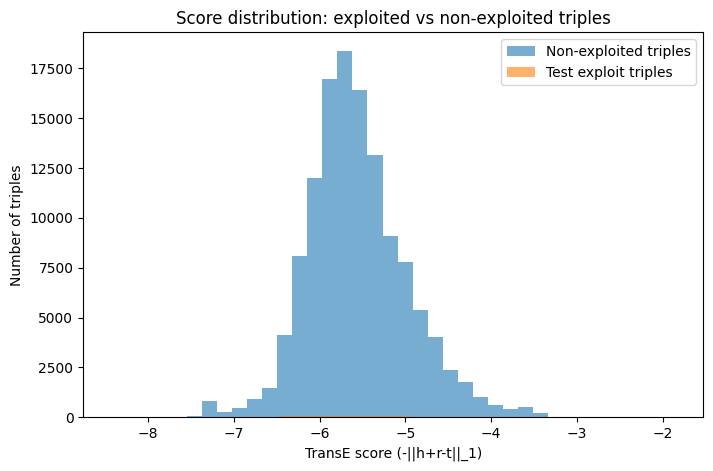

Mean score of test exploits: -5.197563
Mean score of non-exploited triples: -5.5621476


In [59]:
def score_and_plot_triples(model, test_triples, non_exploit_triples, device='cpu', bins=30):
    model.to(device)
    model.eval()
    # Convert to tensors
    test_tensor = torch.tensor(np.array(test_triples), dtype=torch.long, device=device)
    non_tensor = torch.tensor(np.array(non_exploit_triples), dtype=torch.long, device=device)
    with torch.no_grad():
        test_scores = model.predict(test_tensor).cpu().numpy()
        non_scores = model.predict(non_tensor).cpu().numpy()
    plt.figure(figsize=(8,5))
    plt.hist(non_scores, bins=bins, alpha=0.6, label='Non-exploited triples')
    plt.hist(test_scores, bins=bins, alpha=0.6, label='Test exploit triples')
    plt.xlabel('TransE score (-||h+r-t||_1)')
    plt.ylabel('Number of triples')
    plt.title('Score distribution: exploited vs non-exploited triples')
    plt.legend()
    plt.show()
    return {
        "test_scores": test_scores,
        "non_exploit_scores": non_scores
    }

result = score_and_plot_triples(
    model=model,
    test_triples=test_exploits,
    non_exploit_triples=non_exp_trips,
    device='cuda'
)

print("Mean score of test exploits:", np.mean(result["test_scores"]))
print("Mean score of non-exploited triples:", np.mean(result["non_exploit_scores"]))


Since we cannot see the difference, we can normalize so that we plot density instead of raw counts.

In [60]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def score_and_plot_triples_density(
    model,
    test_triples,
    non_exploit_triples,
    device='cpu',
    bins=30
):
    model.to(device)
    model.eval()
    test_tensor = torch.tensor(
        np.array(test_triples), dtype=torch.long, device=device
    )
    non_tensor = torch.tensor(
        np.array(non_exploit_triples), dtype=torch.long, device=device
    )
    with torch.no_grad():
        test_scores = model.predict(test_tensor).cpu().numpy()
        non_scores = model.predict(non_tensor).cpu().numpy()
    # Determine shared bin range
    all_scores = np.concatenate([test_scores, non_scores])
    bin_range = (all_scores.min(), all_scores.max())
    plt.figure(figsize=(8, 5))
    plt.hist(
        non_scores,
        bins=bins,
        range=bin_range,
        density=True, # normalize, not raw counts
        alpha=0.6,
        label='Non-exploited triples'
    )
    plt.hist(
        test_scores,
        bins=bins,
        range=bin_range,
        density=True,
        alpha=0.6,
        label='Exploited triples'
    )
    plt.xlabel('TransE score (-||h + r - t||)')
    plt.ylabel('Probability density')
    plt.title('Score distribution (density-normalized)')
    plt.legend()
    plt.show()
    
    return {
        "test_scores": test_scores,
        "non_exploit_scores": non_scores
    }


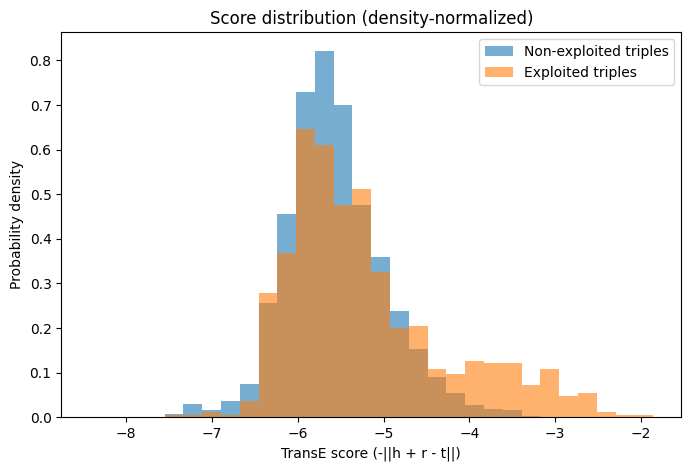

Mean score of exploited CVEs: -5.197563
Mean score of non-exploited CVEs: -5.5621476


In [61]:
result = score_and_plot_triples_density(
    model=model,
    test_triples=test_exploits,
    non_exploit_triples=non_exp_trips,
    device='cuda', 
    bins=30
)

print("Mean score of exploited CVEs:", np.mean(result["test_scores"]))
print("Mean score of non-exploited CVEs:", np.mean(result["non_exploit_scores"]))
